[![](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mbanuelos/grad_math_modeling/blob/main/Lectures/Module1_BiologyDisease/01_Python_SolvingODEs.ipynb#copy=true)

# MATH 232 - Math Models w/ Tech
Python Intro & ODEs Review
Instructor: Prof. Mario Bañuelos 

## Outline

* [Intro to Python & Plotting](#python-plot)
* [ODEs Review](#ode-review)
* [ODEs - Population Dynamics](#ode-pop)
    * [Ebola](#ebola)
* [Equilibria](#eq)

In [2]:
# Import necessary packages
from IPython.display import HTML, Image
# we are importing numpy and giving it the shortcut 'np'
import numpy as np
# import plotting packages
import matplotlib.pyplot as plt
#import plotly.graph_objects as go

In [6]:
# create some comments!

This is my favorite mathematical expression, $x^2$


$$
y = f(x)
$$

Put some notes here for yourself.

# Python & Plotting <a id='python-plot'></a>

To begin plotting, we need something to plot.

In [1]:
#help(np.linspace)

In [3]:
np.linspace(0,15)

array([ 0.        ,  0.30612245,  0.6122449 ,  0.91836735,  1.2244898 ,
        1.53061224,  1.83673469,  2.14285714,  2.44897959,  2.75510204,
        3.06122449,  3.36734694,  3.67346939,  3.97959184,  4.28571429,
        4.59183673,  4.89795918,  5.20408163,  5.51020408,  5.81632653,
        6.12244898,  6.42857143,  6.73469388,  7.04081633,  7.34693878,
        7.65306122,  7.95918367,  8.26530612,  8.57142857,  8.87755102,
        9.18367347,  9.48979592,  9.79591837, 10.10204082, 10.40816327,
       10.71428571, 11.02040816, 11.32653061, 11.63265306, 11.93877551,
       12.24489796, 12.55102041, 12.85714286, 13.16326531, 13.46938776,
       13.7755102 , 14.08163265, 14.3877551 , 14.69387755, 15.        ])

In [7]:
# create data to plot (exponential growth)
t = np.linspace(0,15)
r1 = 1
r2 = 0.5
n0 = 1
n_cont1 = np.exp(r1*t) * n0
n_cont2 = np.exp(r2*t) * n0

In [8]:
n_cont1

array([1.00000000e+00, 1.35814860e+00, 1.84456762e+00, 2.50519693e+00,
       3.40242971e+00, 4.62100514e+00, 6.27601167e+00, 8.52375646e+00,
       1.15765279e+01, 1.57226452e+01, 2.13536885e+01, 2.90014822e+01,
       3.93883224e+01, 5.34951950e+01, 7.26544242e+01, 9.86755045e+01,
       1.34015998e+02, 1.82013641e+02, 2.47201571e+02, 3.35736468e+02,
       4.55980014e+02, 6.19288618e+02, 8.41085969e+02, 1.14231973e+03,
       1.55143995e+03, 2.10708599e+03, 2.86173589e+03, 3.88666259e+03,
       5.27866536e+03, 7.16921197e+03, 9.73685520e+03, 1.32240963e+04,
       1.79602878e+04, 2.43927398e+04, 3.31289654e+04, 4.49940579e+04,
       6.11086168e+04, 8.29945824e+04, 1.12718976e+05, 1.53089119e+05,
       2.07917773e+05, 2.82383233e+05, 3.83518392e+05, 5.20874967e+05,
       7.07425608e+05, 9.60789099e+05, 1.30489437e+06, 1.77224046e+06,
       2.40696590e+06, 3.26901737e+06])

## Matplotlib



`matplotlib.pyplot` is a collection of command style functions that make matplotlib work like MATLAB. 

Each pyplot function makes some change to a figure: e.g., creates a figure, creates a plotting area in a figure, plots some lines in a plotting area, decorates the plot with labels, etc.

**<a href=https://matplotlib.org/3.1.0/tutorials/introductory/pyplot.html> Pyplot Tutorials </a>**

To get started, simply use 
```
plt.plot(x, y)
```

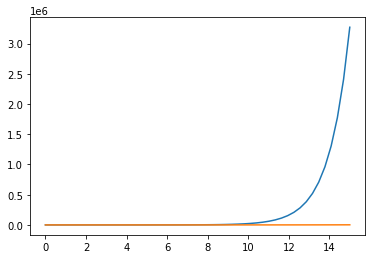

In [10]:
# line plot
plt.plot(t, n_cont1, t, n_cont2)
plt.show()

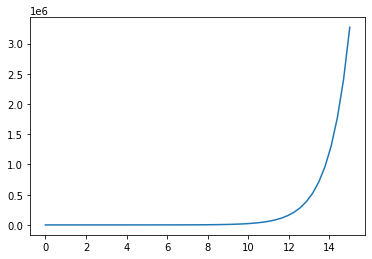

In [12]:
# creating a plt.figure object, adding to it, then saving it
fig_mp = plt.figure()
plt.plot(t, n_cont1)
plt.show()
# saving the figure
fig_mp.savefig("matplotlib_exp_growth.png", bbox_inches='tight')

## Plotly



`plotly` is an interactive, open-source plotting library that supports over 40 unique chart types covering a wide range of statistical, financial, geographic, scientific, and 3-dimensional use-cases.

When combined with Dash, you can create <a href=https://dash-gallery.plotly.host/dash-opioid-epidemic/> interactive applications </a> (similar to shiny apps in R)

**<a href="https://plotly.com/python/basic-charts/"> Plotly Tutorials </a>**

To get started with a line chart, initiate a figure with
```
fig = go.Figure()
fig.add_trace(go.Scatter(x=x, y=y))
```

In [ ]:
# Install a pip package in the current Jupyter kernel
#import sys
#!{sys.executable} -m pip install plotly==5.10.0

In [16]:
# Create traces
fig = go.Figure()
# add line plot for continuous 1 (with r = 1)
fig.add_trace(go.Scatter(x=t, y=n_cont1, name='$r_{cont.}=1$'))
# add line plot for continous 2 (with r = 0.5)
fig.add_trace(go.Scatter(x=t, y=n_cont2, name='$r_{cont.}=0.5$)'))

# updated the y-axis range
fig.update_yaxes(range=[0, 1000])

# Edit the layout (change title, x-axis title, y-axis title)
fig.update_layout(title='Simulated Population Growth',
                  xaxis_title='Time',
                 yaxis_title='Population Size')

In [16]:
# Create traces
fig = go.Figure()
# add line plot for continuous 1 (with r = 1)
fig.add_trace(go.Scatter(x=t, y=n_cont1, name='$r_{cont.}=1$'))
# add line plot for continous 2 (with r = 0.5)
fig.add_trace(go.Scatter(x=t, y=n_cont2, name='$r_{cont.}=0.5$)'))

# updated the y-axis range
fig.update_yaxes(range=[0, 1000])

# Edit the layout (change title, x-axis title, y-axis title)
fig.update_layout(title='Simulated Population Growth',
                  xaxis_title='Time',
                 yaxis_title='Population Size')

# ODE Review <a id='ode-review'></a>

A differential equation is any equation which contains derivatives, either ordinary derivatives or partial derivatives.

## Separable DEs

A separable differential equation is any differential equation that we can write in the following form,

\begin{equation}
N\left( y \right)\frac{{dy}}{{dx}} = M\left( x \right).
\end{equation}

Feel free to review this topic <a href="https://tutorial.math.lamar.edu/classes/de/Separable.aspx"> here </a>


### Example

From the Google Form question, 
\begin{equation}
\frac{{dy}}{{dx}} = 6{y^2}x\hspace{0.25in}\,\,\,y\left( 1 \right) = \frac{1}{{25}}
\end{equation}


\begin{align*}
{y^{ - 2}}dy & = 6x\,dx\\\int{{{y^{ - 2}}dy}} 
& = \int{{6x\,dx}}\\ - \frac{1}{y} 
& = 3{x^2} + c
\end{align*}

Solve for $c$ using the initial condition and then we arrive at

$$
\begin{align*} 
- \frac{1}{y} & = 3{x^2} - 28\\ y\left( x \right) 
& = \frac{1}{{28 - 3{x^2}}}\end{align*}
$$

# Population Dynamics <a id='ode-pop'></a>

We will investigate how a population $p(t)$ changes in time using a variety of models.

### Translate the Model

Translate the following population model,

$$
\frac{dp}{dt} = c; \quad p(0) = p_0
$$

* what is it saying?
* what is it not saying?
* what modifications would you introduce and how would you interpret them?

### Malthusian Model (exponential growth)

Named for the British economist Thomas R. Malthus (1766–1834), the Malthusian model assumes that both the birth rate of a population and the death rate of a population are proportional to the current size of the population. 

Letting $r$ represent the growth parameter, we write,

$$
\frac{dp}{dt} = rp; \quad p(0) = p_0
$$

**Discussion Q:** What is one drawback of this model?

## Ebola <a id='ebola'></a>

In [6]:
# import pandas package
import pandas as pd
# url for Ebola cases 
url = "https://www.dropbox.com/s/oq6k1aib0602v9b/ebola_previous-case-counts.csv?dl=1"

In [7]:
# read in data, specifying date column
df = pd.read_csv(url, parse_dates=['WHO report date'])
df
# sort data frame by date (oldest to most recent)
df.sort_values(by='WHO report date',ascending=True)

,WHO report date,"Total Cases, Guinea","Total Deaths, Guinea","Total Cases, Liberia","Total Deaths, Liberia","Total Cases, Sierra Leone","Total Deaths, Sierra Leone",Total Cases,Total Deaths
264,2014-03-25,86,59,0,0,0,0,86,59
263,2014-03-26,86,60,0,0,0,0,86,60
262,2014-03-27,103,66,8,6,6,5,117,77
261,2014-03-31,112,70,8,6,0,0,120,76
260,2014-04-01,122,80,8,2,0,0,130,82
...,...,...,...,...,...,...,...,...,...
4,2016-02-17,3804,2536,10675,4809,14124,3956,28603,11301
3,2016-03-03,3804,2536,10675,4809,14124,3956,28603,11301
2,2016-03-23,3809,2540,10675,4809,14124,3956,28608,11305
1,2016-03-30,3811,2543,10675,4809,14124,3956,28610,11308


In [8]:
# we can also select certain columns of a dataframe
df['Total Cases, Liberia']

0      10678
1      10675
2      10675
3      10675
4      10675
       ...  
260        8
261        8
262        8
263        0
264        0
Name: Total Cases, Liberia, Length: 265, dtype: int64

In [9]:
# Create traces
fig = go.Figure()
fig.add_trace(go.Scatter(x=df['WHO report date'], y=df['Total Cases']))

# Edit the layout
fig.update_layout(title='Ebola - 2014',
                   xaxis_title='Date',
                   yaxis_title='Total # of Cases')

In [10]:
fig.update_xaxes(
    rangeslider_visible=True,
    rangeselector=dict(
        buttons=list([
            dict(count=1, label="1m", step="month", stepmode="backward"),
            dict(count=6, label="6m", step="month", stepmode="backward"),
            dict(count=1, label="1y", step="year", stepmode="backward"),
            dict(step="all")
        ])
    )
)
fig.show()

Let's assume that the cases in West Africa infected with the Ebola virus grow exponentially:

$$
P(t) = p_0 e^{rt},
$$

where $t$ is time in months and $P(t)$ is the number of cases at time $t$. Let $t=0$ represent March 2014. 

During this time, there were $49$ cases of Ebola. After 3 months, there were $528$ cases. 

**Q:** 
* Determine $r$ and $p_0$ from this information.
* Use your exponential growth model to estimate the time it will take for the outbreak to reach $5,000$ cases.
* How well does your answer match up to the data above?
* Plot your model on the same plot as the data.
* **How do $r$ and $p_0$ change if $t$ is measured in days, or if we consider only one country at a time?**

In [3]:
r = 1/3 * np.log(528/49)
r

0.7924253285318783

A function to make this easier ...

In [7]:
def calc_r(p0, t1, p_t1):
    a = 1/t1
    b = np.log(p_t1/p0)
    return a*b

In [10]:
r2 = calc_r(p0 = 49, t1 = 3, p_t1=528)
r2

0.7924253285318783

## Logistic Growth

Introduced by the Belgian mathematician Pierre Verhulst in about 1838, the logistic model introduces a *carrying capacity* $K$, the greatest population an environment can sustain. We have,

$$
\frac{d p}{dt} = rp\left( 1 - \frac{p}{K}\right); \quad p(0) = p_0
$$

**Q:** What is the general solution for $p(t)$?

If we think about the sigmoid function $\frac{1}{1+e^{-x}}$, what differential equation does it solve?

$$
f' = f(1-f)
$$

# Equilibria / Steady-state <a id='eq'></a>

An **equilibrium point** is some point at which a population does not change anymore: $$\frac{dp}{dt} = 0.$$ In the case of the logistic equation, we can find all equilibrium points by solving (for $p$) the algebraic equation,

$$
rp \left( 1 - \frac{p}{K}\right) = 0
$$

**Q:** Based on your solutions, what conclusions can you draw?